In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [ ]:
df = pd.read_excel("/content/data_sampah_nasional.xlsx")

print("Data Awal:")
print(df.head())


Data Awal:
   No Provinsi           Kota/Kabupaten     Jenis TPA Verifikasi Lapangan  \
0   1     Aceh       Kabupaten Simeulue  Open Dumping               Sudah   
1   2     Aceh   Kabupaten Aceh Singkil  Open Dumping               Sudah   
2   3     Aceh   Kabupaten Aceh Selatan  Open Dumping               Sudah   
3   4     Aceh  Kabupaten Aceh Tenggara  Open Dumping               Sudah   
4   5     Aceh     Kabupaten Aceh Timur  Open Dumping               Sudah   

  Nilai Kinerja PS                           Progress SA Timbulan  \
0                -                                  57.9   39 tpd   
1                -  Tidak dapat dikunjungi karena banjir   55 tpd   
2                -                                 15.95   97 tpd   
3                -                                  45.8  116 tpd   
4                -                                  41.2  185 tpd   

  % S. Terkelola % S. Belum Terkelola       waktu_scraping  
0           0,13                99,87  2026-05-15 

In [ ]:
print("\nInfo Data:")
print(df.info())


Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   No                    514 non-null    int64 
 1   Provinsi              514 non-null    object
 2   Kota/Kabupaten        514 non-null    object
 3   Jenis TPA             484 non-null    object
 4   Verifikasi Lapangan   514 non-null    object
 5   Nilai Kinerja PS      514 non-null    object
 6   Progress SA           514 non-null    object
 7   Timbulan              514 non-null    object
 8   % S. Terkelola        514 non-null    object
 9   % S. Belum Terkelola  514 non-null    object
 10  waktu_scraping        514 non-null    object
dtypes: int64(1), object(10)
memory usage: 44.3+ KB
None


# Data Cleaning

In [ ]:
# Menghapus spasi berlebih pada nama kolom
df.columns = df.columns.str.strip()

In [ ]:
# Mengisi missing value pada Jenis TPA
df['Jenis TPA'] = df['Jenis TPA'].fillna('Tidak Diketahui')

In [ ]:
# Membersihkan kolom Timbulan
df['Timbulan'] = (
    df['Timbulan']
    .str.replace('tpd', '', regex=False)
    .str.strip()
)

df['Timbulan'] = pd.to_numeric(df['Timbulan'], errors='coerce')

In [ ]:
# Membersihkan kolom persentase
persentase_cols = ['Progress SA',
                   '% S. Terkelola',
                   '% S. Belum Terkelola']

for col in persentase_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.replace('%', '', regex=False)
        .str.strip()
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df

,No,Provinsi,Kota/Kabupaten,Jenis TPA,Verifikasi Lapangan,Nilai Kinerja PS,Progress SA,Timbulan,% S. Terkelola,% S. Belum Terkelola,waktu_scraping
0,1,Aceh,Kabupaten Simeulue,Open Dumping,Sudah,-,57.90,39.00,0.13,99.87,2026-05-15 13:25:27
1,2,Aceh,Kabupaten Aceh Singkil,Open Dumping,Sudah,-,NaN,55.00,0.04,99.96,2026-05-15 13:25:27
2,3,Aceh,Kabupaten Aceh Selatan,Open Dumping,Sudah,-,15.95,97.00,0.01,99.99,2026-05-15 13:25:27
3,4,Aceh,Kabupaten Aceh Tenggara,Open Dumping,Sudah,-,45.80,116.00,0.28,99.72,2026-05-15 13:25:27
4,5,Aceh,Kabupaten Aceh Timur,Open Dumping,Sudah,-,41.20,185.00,0.00,100.00,2026-05-15 13:25:27
...,...,...,...,...,...,...,...,...,...,...,...
509,510,Sumatera Utara,Kota Tebing Tinggi,Controlled Landfill,Sudah,-,NaN,128.00,0.97,99.03,2026-05-15 13:25:27
510,511,Sumatera Utara,Kota Medan,Sanitary Landfill,Sudah,-,NaN,1.74,0.71,99.29,2026-05-15 13:25:27
511,512,Sumatera Utara,Kota Binjai,Open Dumping,Sudah,-,32.75,154.00,0.21,99.79,2026-05-15 13:25:27
512,513,Sumatera Utara,Kota Padangsidimpuan,Open Dumping,Sudah,-,NaN,165.00,0.16,99.84,2026-05-15 13:25:27


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   No                    514 non-null    int64  
 1   Provinsi              514 non-null    object 
 2   Kota/Kabupaten        514 non-null    object 
 3   Jenis TPA             514 non-null    object 
 4   Verifikasi Lapangan   514 non-null    object 
 5   Nilai Kinerja PS      514 non-null    object 
 6   Progress SA           222 non-null    float64
 7   Timbulan              514 non-null    float64
 8   % S. Terkelola        514 non-null    float64
 9   % S. Belum Terkelola  514 non-null    float64
 10  waktu_scraping        514 non-null    object 
dtypes: float64(4), int64(1), object(6)
memory usage: 44.3+ KB


In [ ]:
# cek missing value
print("\nMissing Value:")
print(df.isnull().sum())


Missing Value:
No                        0
Provinsi                  0
Kota/Kabupaten            0
Jenis TPA                 0
Verifikasi Lapangan       0
Nilai Kinerja PS          0
Progress SA             292
Timbulan                  0
% S. Terkelola            0
% S. Belum Terkelola      0
waktu_scraping            0
dtype: int64


In [ ]:
df = df.drop(['No', 'waktu_scraping','Progress SA'], axis=1)

# EDA

In [ ]:
# pengaturan tampilan
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

MERAH = '#d62828'
KUNING = '#fcbf49'
HIJAU = '#2a9d8f'

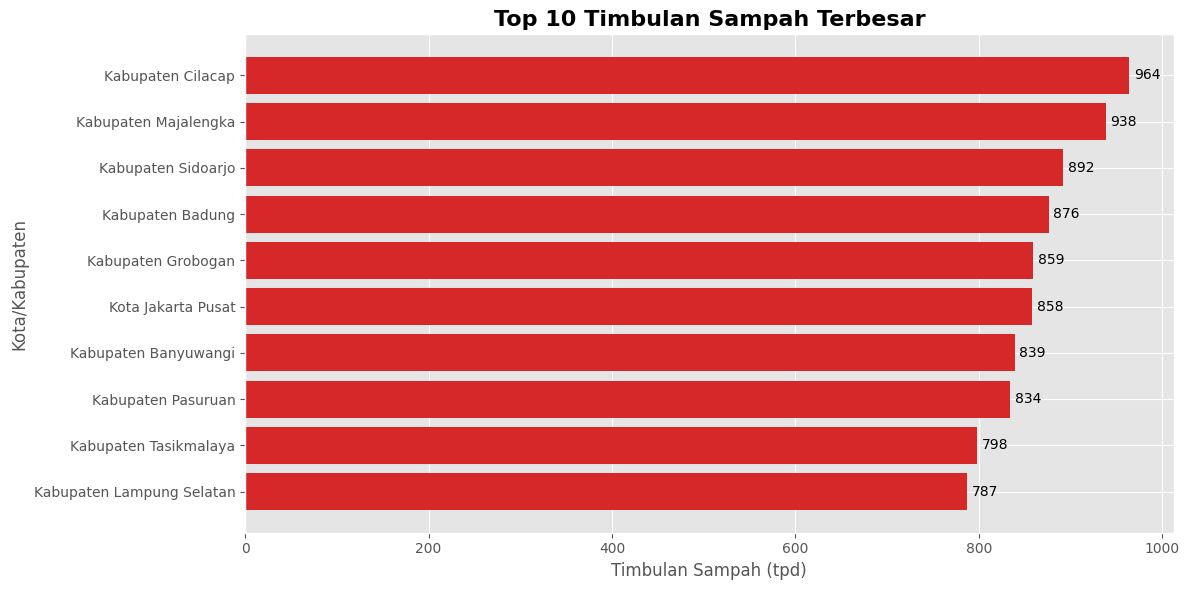

In [ ]:
# VISUALISASI 1
# TOP 10 TIMBULAN SAMPAH TERBESAR
top_sampah = (
    df.sort_values(by='Timbulan', ascending=False)
    .head(10)
)

warna_bar = [
    MERAH
]

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_sampah['Kota/Kabupaten'],
    top_sampah['Timbulan'],
    color=warna_bar
)

plt.xlabel('Timbulan Sampah (tpd)', fontsize=12)
plt.ylabel('Kota/Kabupaten', fontsize=12)
plt.title('Top 10 Timbulan Sampah Terbesar', fontsize=16, weight='bold')

# label angka
for bar in bars:
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.0f}',
        va='center'
    )

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


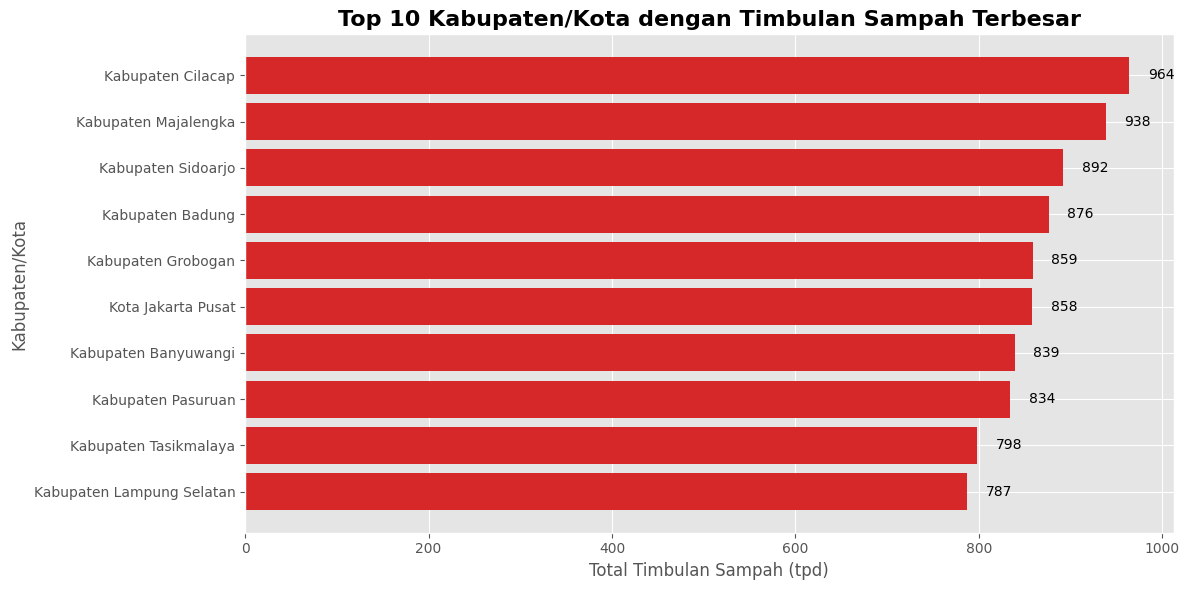

In [ ]:
# TOP 10 KABUPATEN/KOTA TIMBULAN SAMPAH TERBESAR
top_kab_timbulan = (
    df.groupby('Kota/Kabupaten')['Timbulan']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_kab_timbulan.index,
    top_kab_timbulan.values,
    color=MERAH
)

for bar in bars:
    plt.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():,.0f}',
        va='center'
    )

plt.title(
    'Top 10 Kabupaten/Kota dengan Timbulan Sampah Terbesar',
    fontsize=16,
    weight='bold'
)

plt.xlabel('Total Timbulan Sampah (tpd)')
plt.ylabel('Kabupaten/Kota')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

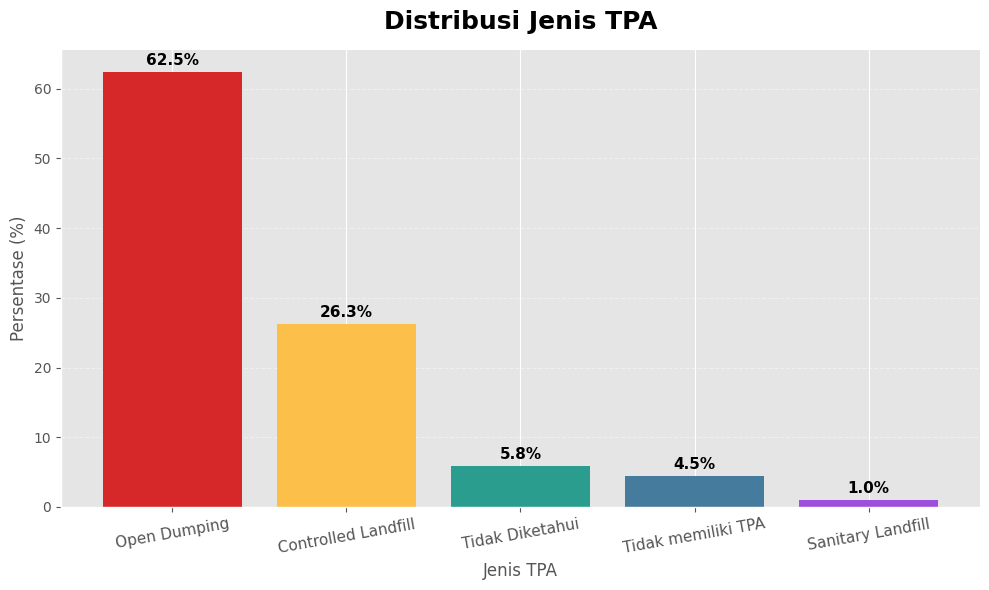

In [ ]:
# DISTRIBUSI JENIS TPA (BAR CHART PERSENTASE)
# Hitung persentase
jenis_tpa = df['Jenis TPA'].value_counts(normalize=True) * 100

# Warna batang
warna_bar = [
    '#d62828',
    '#fcbf49',
    '#2a9d8f',
    '#457b9d',
    '#9d4edd'
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    jenis_tpa.index,
    jenis_tpa.values,
    color=warna_bar
)

# Menampilkan angka persentase di atas batang
for bar in bars:
    tinggi = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        tinggi + 1,
        f'{tinggi:.1f}%',
        ha='center',
        fontsize=11,
        weight='bold'
    )

# Judul dan label
plt.title(
    'Distribusi Jenis TPA',
    fontsize=18,
    weight='bold',
    pad=15
)

plt.ylabel('Persentase (%)', fontsize=12)
plt.xlabel('Jenis TPA', fontsize=12)

# Rotasi label biar rapi
plt.xticks(rotation=10, fontsize=11)

# Grid horizontal
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Hilangkan garis atas dan kanan
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

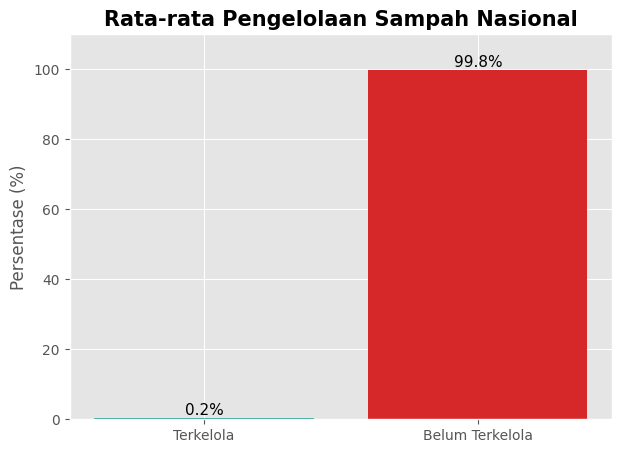

In [ ]:
# TERKELOLA VS BELUM TERKELOLA

rata_terkelola = df['% S. Terkelola'].mean()
rata_belum = df['% S. Belum Terkelola'].mean()

kategori = ['Terkelola', 'Belum Terkelola']
nilai = [rata_terkelola, rata_belum]

plt.figure(figsize=(7,5))

bars = plt.bar(
    kategori,
    nilai,
    color=[HIJAU, MERAH]
)

# label angka
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{bar.get_height():.1f}%',
        ha='center',
        fontsize=11
    )

plt.ylabel('Persentase (%)')
plt.title(
    'Rata-rata Pengelolaan Sampah Nasional',
    fontsize=15,
    weight='bold'
)

plt.ylim(0, 110)

plt.show()


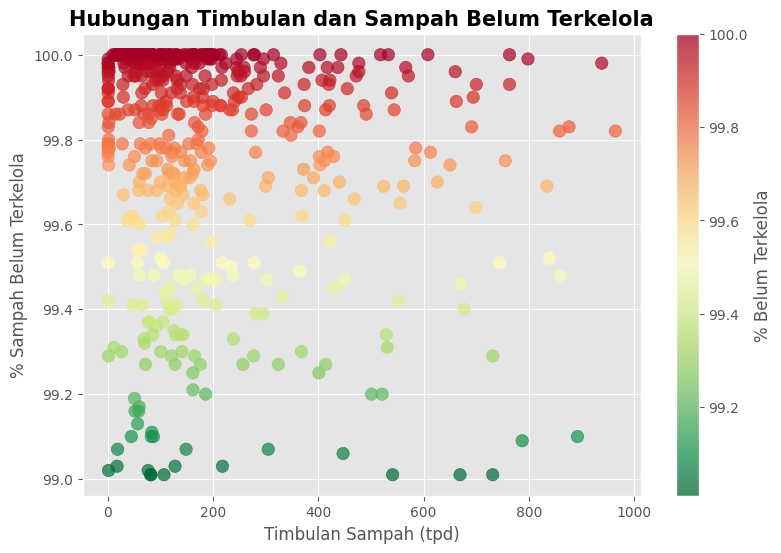

In [ ]:
# SCATTER TIMBULAN VS BELUM TERKELOLA
plt.figure(figsize=(9,6))

scatter = plt.scatter(
    df['Timbulan'],
    df['% S. Belum Terkelola'],
    c=df['% S. Belum Terkelola'],
    cmap='RdYlGn_r',
    s=80,
    alpha=0.7
)

plt.colorbar(scatter, label='% Belum Terkelola')

plt.xlabel('Timbulan Sampah (tpd)')
plt.ylabel('% Sampah Belum Terkelola')

plt.title(
    'Hubungan Timbulan dan Sampah Belum Terkelola',
    fontsize=15,
    weight='bold'
)

plt.show()

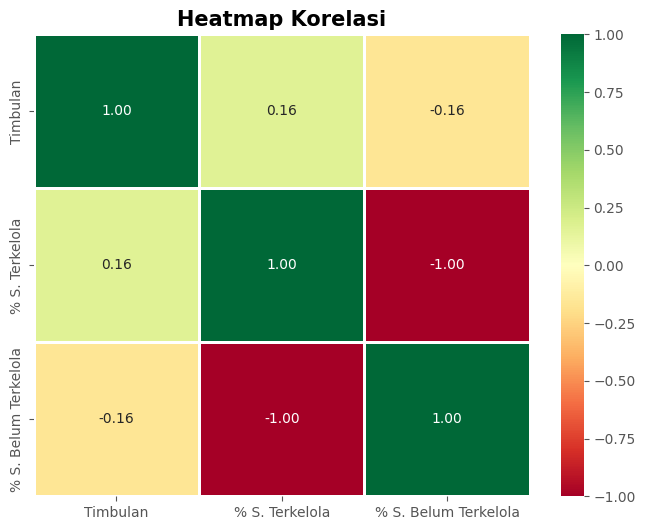

In [ ]:
# HEATMAP KORELASI
numerik = df[[
    'Timbulan',
    '% S. Terkelola',
    '% S. Belum Terkelola'
]]

plt.figure(figsize=(8,6))

sns.heatmap(
    numerik.corr(),
    annot=True,
    cmap='RdYlGn',
    linewidths=1,
    fmt='.2f'
)

plt.title(
    'Heatmap Korelasi',
    fontsize=15,
    weight='bold'
)

plt.show()

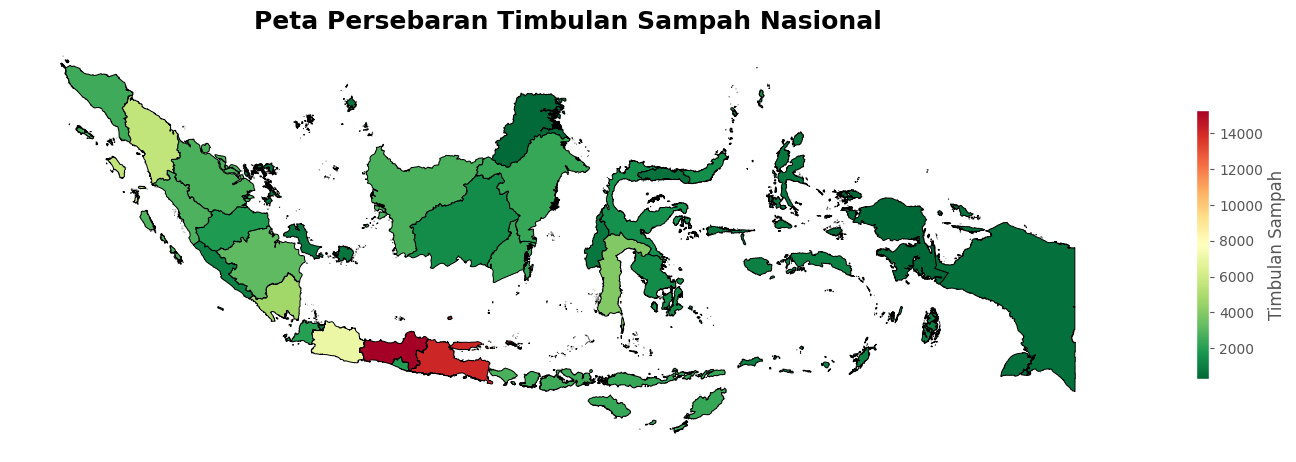

In [ ]:
# NORMALISASI NAMA PROVINSI
gdf = gpd.read_file('/content/gadm41_IDN_1.json')
df['Provinsi'] = (
    df['Provinsi']
    .str.upper()
    .str.strip()
)

gdf['NAME_1'] = (
    gdf['NAME_1']
    .str.upper()
    .str.strip()
)

# MAPPING GEOJSON → DATASET

name_map = {

    'ACEH'              : 'ACEH',
    'BALI'              : 'BALI',
    'BANGKABELITUNG'    : 'KEPULAUAN BANGKA BELITUNG',
    'BANTEN'            : 'BANTEN',
    'BENGKULU'          : 'BENGKULU',
    'GORONTALO'         : 'GORONTALO',
    'JAKARTARAYA'       : 'DKI JAKARTA',
    'JAMBI'             : 'JAMBI',
    'JAWABARAT'         : 'JAWA BARAT',
    'JAWATENGAH'        : 'JAWA TENGAH',
    'JAWATIMUR'         : 'JAWA TIMUR',
    'KALIMANTANBARAT'   : 'KALIMANTAN BARAT',
    'KALIMANTANSELATAN' : 'KALIMANTAN SELATAN',
    'KALIMANTANTENGAH'  : 'KALIMANTAN TENGAH',
    'KALIMANTANTIMUR'   : 'KALIMANTAN TIMUR',
    'KALIMANTANUTARA'   : 'KALIMANTAN UTARA',
    'KEPULAUANRIAU'     : 'KEPULAUAN RIAU',
    'LAMPUNG'           : 'LAMPUNG',
    'MALUKU'            : 'MALUKU',
    'MALUKUUTARA'       : 'MALUKU UTARA',
    'NUSATENGGARABARAT' : 'NUSA TENGGARA BARAT',
    'NUSATENGGARATIMUR' : 'NUSA TENGGARA TIMUR',
    'PAPUA'             : 'PAPUA',
    'PAPUABARAT'        : 'PAPUA BARAT',
    'RIAU'              : 'RIAU',
    'SULAWESIBARAT'     : 'SULAWESI BARAT',
    'SULAWESISELATAN'   : 'SULAWESI SELATAN',
    'SULAWESITENGAH'    : 'SULAWESI TENGAH',
    'SULAWESITENGGARA'  : 'SULAWESI TENGGARA',
    'SULAWESIUTARA'     : 'SULAWESI UTARA',
    'SUMATERABARAT'     : 'SUMATERA BARAT',
    'SUMATERASELATAN'   : 'SUMATERA SELATAN',
    'SUMATERAUTARA'     : 'SUMATERA UTARA',
    'YOGYAKARTA'        : 'DI YOGYAKARTA'
}

gdf['Provinsi'] = gdf['NAME_1'].map(name_map)


# AGREGASI DATA
timbulan_prov = (
    df.groupby('Provinsi')['Timbulan']
    .sum()
    .reset_index()
)

peta = gdf.merge(
    timbulan_prov,
    on='Provinsi',
    how='left'
)
# VISUALISASI PETA
fig, ax = plt.subplots(figsize=(18,10))

peta.plot(
    column='Timbulan',

    cmap='RdYlGn_r',

    linewidth=0.7,
    edgecolor='black',

    legend=True,

    legend_kwds={
        'shrink': 0.35,
        'label': 'Timbulan Sampah'
    },

    ax=ax,

    missing_kwds={
        "color": "lightgrey",
        "label": "Tidak Ada Data"
    }
)

ax.set_title(
    'Peta Persebaran Timbulan Sampah Nasional',
    fontsize=18,
    weight='bold'
)

ax.axis('off')

plt.show()

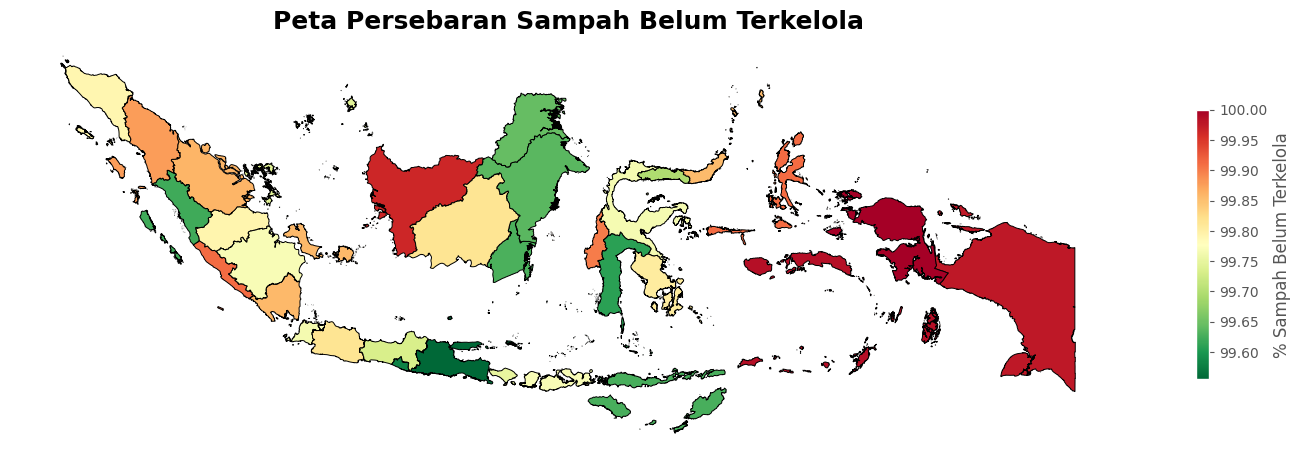

In [ ]:
# PETA PERSEBARAN SAMPAH BELUM TERKELOLA
# agregasi rata-rata sampah belum terkelola
belum_terkelola = (
    df.groupby('Provinsi')['% S. Belum Terkelola']
    .mean()
    .reset_index()
)

# merge dengan geojson
peta_belum = gdf.merge(
    belum_terkelola,
    on='Provinsi',
    how='left'
)

# visualisasi
fig, ax = plt.subplots(figsize=(18,10))

peta_belum.plot(
    column='% S. Belum Terkelola',

    cmap='RdYlGn_r',

    linewidth=0.7,
    edgecolor='black',

    legend=True,

    legend_kwds={
        'shrink': 0.35,
        'label': '% Sampah Belum Terkelola'
    },

    ax=ax,

    missing_kwds={
        "color": "lightgrey",
        "label": "Tidak Ada Data"
    }
)

ax.set_title(
    'Peta Persebaran Sampah Belum Terkelola',
    fontsize=18,
    weight='bold'
)

ax.axis('off')

plt.show()

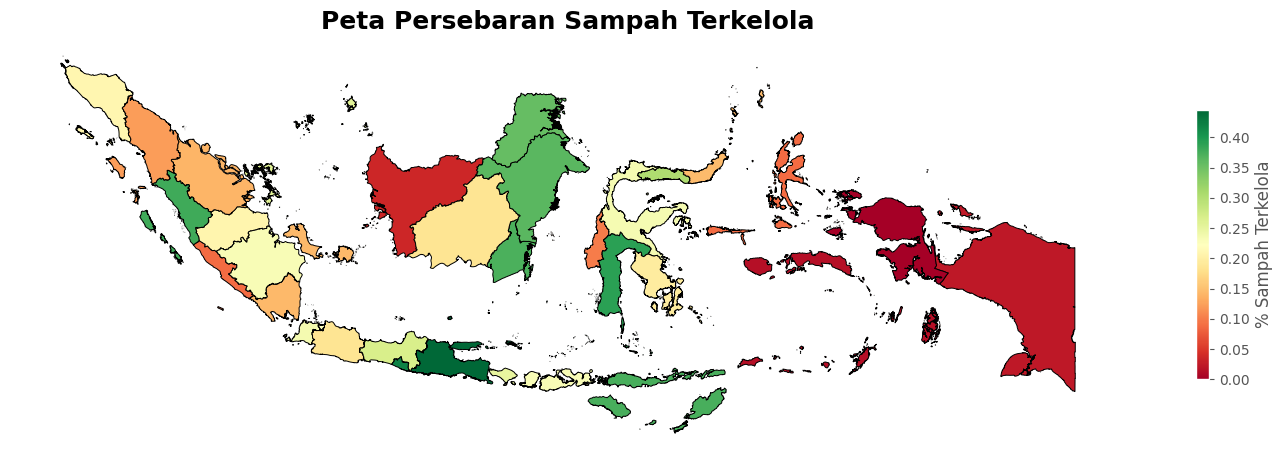

In [ ]:
# PETA PERSEBARAN SAMPAH TERKELOLA
# agregasi rata-rata sampah terkelola
terkelola = (
    df.groupby('Provinsi')['% S. Terkelola']
    .mean()
    .reset_index()
)

# merge dengan geojson
peta_terkelola = gdf.merge(
    terkelola,
    on='Provinsi',
    how='left'
)

# visualisasi
fig, ax = plt.subplots(figsize=(18,10))

peta_terkelola.plot(
    column='% S. Terkelola',

    cmap='RdYlGn',

    linewidth=0.7,
    edgecolor='black',

    legend=True,

    legend_kwds={
        'shrink': 0.35,
        'label': '% Sampah Terkelola'
    },

    ax=ax,

    missing_kwds={
        "color": "lightgrey",
        "label": "Tidak Ada Data"
    }
)

ax.set_title(
    'Peta Persebaran Sampah Terkelola',
    fontsize=18,
    weight='bold'
)

ax.axis('off')

plt.show()

In [ ]:
output_file = 'data_sampah_clean.xlsx'

# Simpan dataframe
df.to_excel(
    output_file,
    index=False
)

print(f'Data berhasil disimpan ke: {output_file}')

Data berhasil disimpan ke: data_sampah_clean.xlsx


---
##  Pertanyaan Bisnis

### 1 · Proporsi Sampah Belum Terkelola & Daerah Kritis
Rata-rata nasional menunjukkan proporsi sampah belum terkelola masih sangat tinggi. Peta choropleth (GeoPandas) memperlihatkan distribusi spasial per provinsi dan mengidentifikasi wilayah yang paling membutuhkan intervensi. Temuan ini menjadi justifikasi urgensi fitur **deteksi sampah berbasis AI** pada *Sortir.in*, karena permasalahan pengelolaan sampah masih nyata dan merata di seluruh Indonesia.

### 2 · Hubungan Timbulan Tinggi dengan Pengelolaan Rendah
Scatter plot timbulan (tpd) vs. persentase belum terkelola, dikombinasikan dengan heatmap korelasi dan peta persebaran per provinsi, mengungkap bahwa daerah dengan produksi sampah tinggi tidak selalu memiliki kapasitas pengelolaan yang memadai. Temuan ini memperkuat perlunya mekanisme insentif seperti fitur tukar poin pada Sortir.in untuk mendorong partisipasi aktif masyarakat dalam pemilahan sampah.
